# TP1 — Visión por Computadora I (completar)

Trabajo Práctico 1 — DVxC

Todo el desarrollo de este TP vive en este notebook.

#### 0.Setup del notebook

In [5]:
import sys

import cv2
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

print(f"Python: {sys.version.split()[0]}")
print(f"NumPy:  {np.__version__}")
print(f"OpenCV: {cv2.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")

Python: 3.14.3
NumPy:  2.4.6
OpenCV: 4.13.0
Matplotlib: 3.10.8


In [6]:
# Configuración de visualización para el notebook
%matplotlib inline
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["image.cmap"] = "gray"

### Parte 1 - Implementación de White Patch

* Cargar las imágenes de /white_patch
* Mostrar los resultados obtenidos y analizar posibles fallas

In [7]:
from pathlib import Path
import tkinter as tk
from tkinter import filedialog

# Extensiones de imagen que vamos a aceptar al buscar archivos
EXTENSIONES_IMAGEN = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}


def listar_rutas_imagenes(carpeta):
    """Devuelve las rutas de imagen encontradas en una carpeta, ordenadas por nombre."""
    return sorted(
        archivo
        for archivo in carpeta.iterdir()
        if archivo.is_file() and archivo.suffix.lower() in EXTENSIONES_IMAGEN
    )


def solicitar_carpeta_imagenes():
    """Muestra un diálogo para que el usuario elija la carpeta con las imágenes."""
    ventana = tk.Tk()
    ventana.withdraw()
    ventana.attributes("-topmost", True)
    carpeta = filedialog.askdirectory(
        title="Seleccioná la carpeta white_patch con las imágenes"
    )
    ventana.destroy()
    return Path(carpeta) if carpeta else None


def solicitar_archivos_imagenes():
    """Muestra un diálogo para elegir una o más imágenes si no hay carpeta disponible."""
    ventana = tk.Tk()
    ventana.withdraw()
    ventana.attributes("-topmost", True)
    rutas = filedialog.askopenfilenames(
        title="Seleccioná las imágenes de white_patch",
        filetypes=[("Imágenes", "*.png *.jpg *.jpeg *.bmp *.tif *.tiff"), ("Todos", "*.*")],
    )
    ventana.destroy()
    return [Path(ruta) for ruta in rutas]


def cargar_imagenes_desde_rutas(rutas):
    """Lee cada imagen con OpenCV y las guarda en un diccionario nombre -> imagen BGR."""
    imagenes = {}
    for ruta in rutas:
        imagen = cv2.imread(str(ruta))
        if imagen is None:
            print(f"No se pudo leer la imagen: {ruta.name}")
            continue
        imagenes[ruta.name] = imagen
    return imagenes


# Intentar cargar desde la carpeta white_patch en la raíz del proyecto
carpeta_white_patch = Path("white_patch")
rutas_imagenes = []

if carpeta_white_patch.is_dir():
    rutas_imagenes = listar_rutas_imagenes(carpeta_white_patch)

# Si no hay carpeta o está vacía, pedir al usuario que indique dónde están las imágenes
if not rutas_imagenes:
    print("No se encontró la carpeta 'white_patch' o no contiene imágenes en la raíz.")
    carpeta_seleccionada = solicitar_carpeta_imagenes()

    if carpeta_seleccionada is not None:
        rutas_imagenes = listar_rutas_imagenes(carpeta_seleccionada)

    # Si el usuario canceló la carpeta o tampoco había imágenes, elegir archivos sueltos
    if not rutas_imagenes:
        print("Seleccioná las imágenes manualmente desde el diálogo.")
        rutas_imagenes = solicitar_archivos_imagenes()

imagenes_white_patch = cargar_imagenes_desde_rutas(rutas_imagenes)

if imagenes_white_patch:
    print(f"Se cargaron {len(imagenes_white_patch)} imagen(es):")
    for nombre in imagenes_white_patch:
        alto, ancho = imagenes_white_patch[nombre].shape[:2]
        print(f"  - {nombre} ({ancho}x{alto})")
else:
    print("No se cargó ninguna imagen.")

Se cargaron 8 imagen(es):
  - test_blue.png (278x100)
  - test_green.png (278x100)
  - test_red.png (276x99)
  - wp_blue.jpg (1200x1600)
  - wp_green.png (363x571)
  - wp_green2.jpg (1200x1600)
  - wp_red.png (481x813)
  - wp_red2.jpg (1200x1600)


In [8]:
def aplicar_white_patch(imagen):
    """
    Algoritmo White Patch para corrección de iluminación.

    Asume que el píxel más brillante de la escena corresponde al blanco puro.
    Escala cada canal de color de forma independiente para que su máximo sea 255,
    reduciendo dominantes cromáticas causadas por la iluminación.
    """
    # Pasar a float32 evita desbordes al escalar los valores de intensidad
    imagen_float = imagen.astype(np.float32)

    # Máximo de cada canal (B, G, R en imágenes cargadas con OpenCV)
    maximos_por_canal = np.max(imagen_float, axis=(0, 1))

    # Factor de escala: 255 / máximo del canal.
    # Si un canal es todo ceros, se deja sin modificar (factor = 1).
    factores_escala = np.where(maximos_por_canal > 0, 255.0 / maximos_por_canal, 1.0)

    # Multiplicar cada canal por su factor (broadcasting sobre filas y columnas)
    imagen_corregida = imagen_float * factores_escala

    # Recortar al rango válido de uint8 y convertir el tipo de dato
    return np.clip(imagen_corregida, 0, 255).astype(np.uint8)

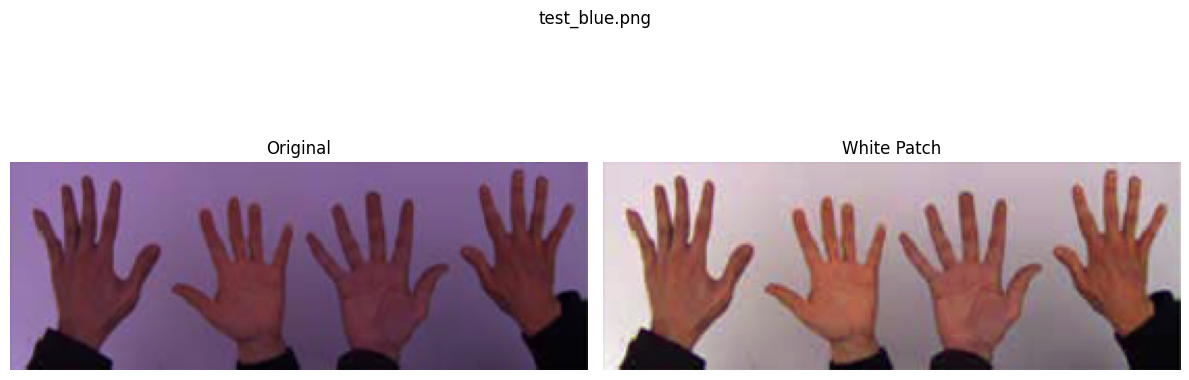

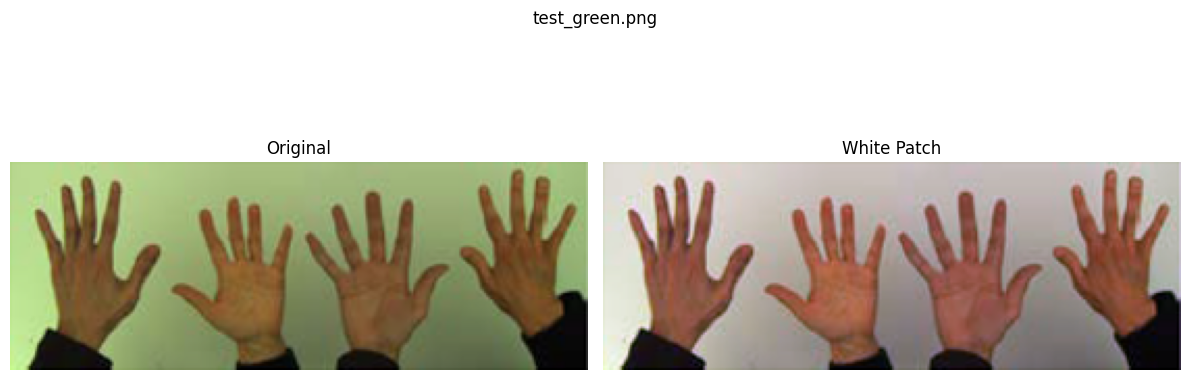

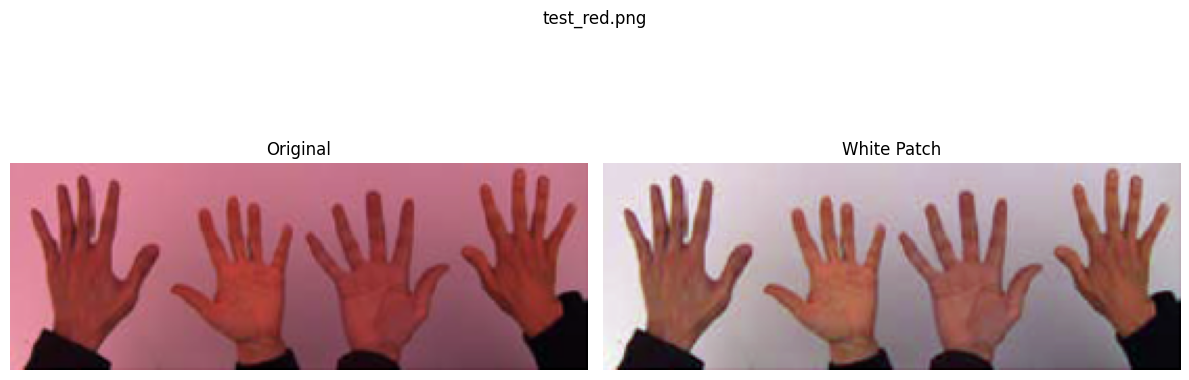

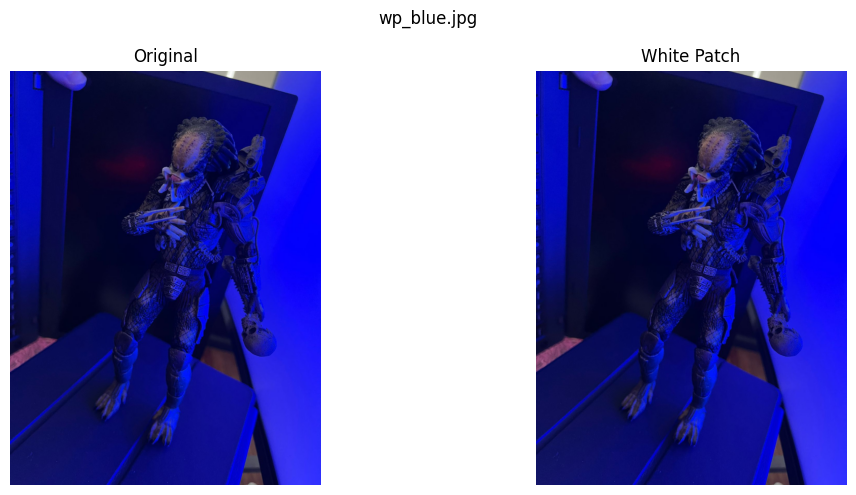

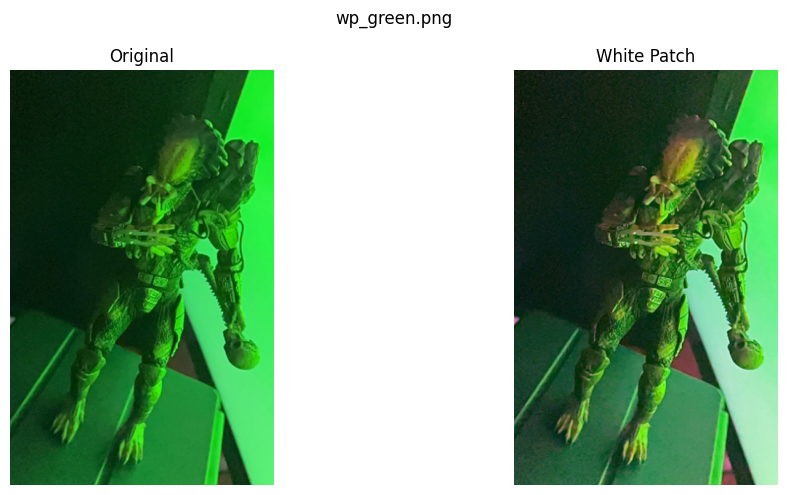

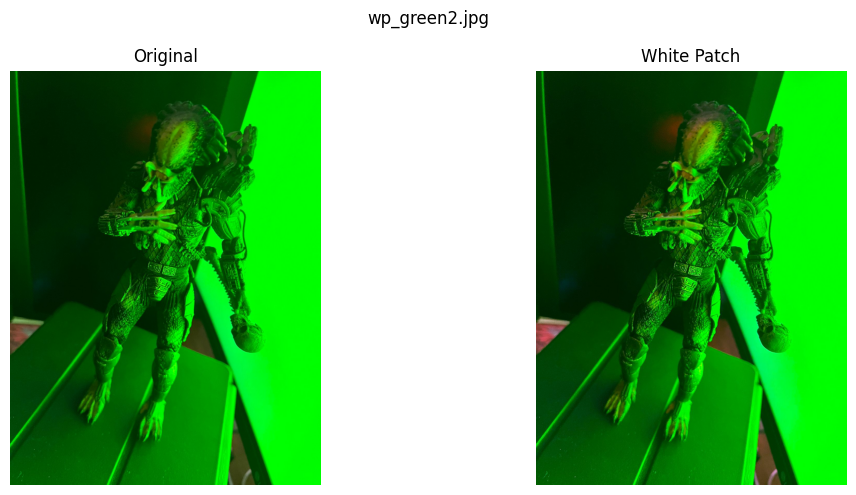

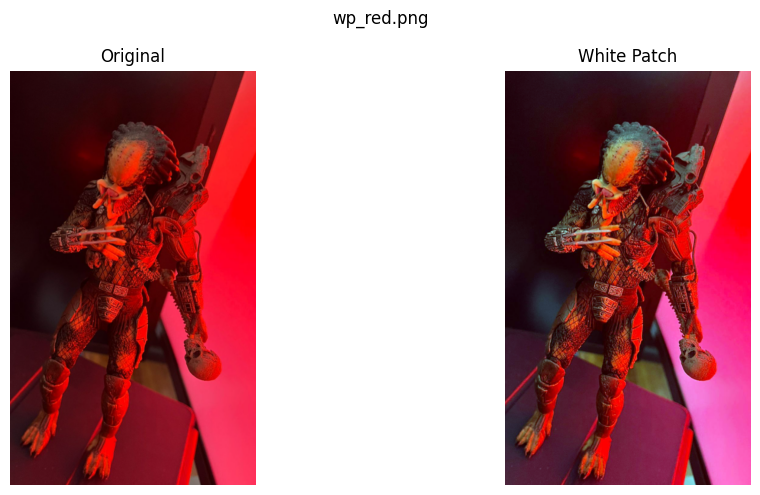

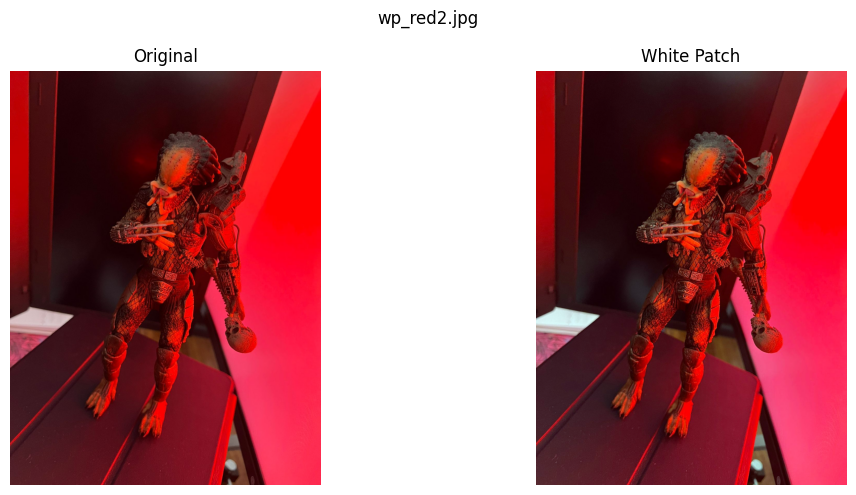

In [9]:
if not imagenes_white_patch:
    print("No hay imágenes cargadas. Ejecutá primero la celda de carga.")
else:
    # Procesar y visualizar cada imagen del conjunto cargado
    for nombre, imagen_original in imagenes_white_patch.items():
        # Aplicar el algoritmo White Patch definido anteriormente
        imagen_corregida = aplicar_white_patch(imagen_original)

        # OpenCV lee en BGR; matplotlib muestra colores correctos en RGB
        original_rgb = cv2.cvtColor(imagen_original, cv2.COLOR_BGR2RGB)
        corregida_rgb = cv2.cvtColor(imagen_corregida, cv2.COLOR_BGR2RGB)

        # Figura con dos subplots: original a la izquierda, corregida a la derecha
        figura, ejes = plt.subplots(1, 2, figsize=(12, 5))

        ejes[0].imshow(original_rgb)
        ejes[0].set_title("Original")
        ejes[0].axis("off")

        ejes[1].imshow(corregida_rgb)
        ejes[1].set_title("White Patch")
        ejes[1].axis("off")

        figura.suptitle(nombre)
        plt.tight_layout()
        plt.show()

#### 1.1 Análisis

### Parte 2 - Análisis con Histogramas

* Cargar las imágenes **img1_tp.png** y **img2_tp.png** con OpenCV en escala de grises y mostrarlas
* Elegir el número de bins mas conveniente y graficar el histograma. Comparar los histogramas entre sí )poner conclusiones)
* Explicar lo que se observa, si tuviera que implementar un modelo de detección/clasificación de imágenes, considera que puede ser de utilidad usar los histogramas como features? 

In [10]:
from pathlib import Path
import tkinter as tk
from tkinter import filedialog

# Nombres de archivo esperados en la raíz del proyecto
ARCHIVO_IMAGEN1_TP = "img1_TP.png"
ARCHIVO_IMAGEN2_TP = "img2_TP.png"


def solicitar_archivo_imagen(titulo):
    """Abre un diálogo para que el usuario elija un archivo de imagen."""
    ventana = tk.Tk()
    ventana.withdraw()
    ventana.attributes("-topmost", True)
    ruta = filedialog.askopenfilename(
        title=titulo,
        filetypes=[("Imágenes", "*.png *.jpg *.jpeg *.bmp *.tif *.tiff"), ("Todos", "*.*")],
    )
    ventana.destroy()
    return Path(ruta) if ruta else None


def resolver_ruta_imagen(nombre_archivo):
    """
    Busca la imagen en el directorio raíz.
    Si no existe, solicita al usuario que la seleccione mediante un diálogo.
    """
    ruta = Path(nombre_archivo)

    # Probar también el nombre en minúsculas (p. ej. img1_tp.png en el repo)
    if not ruta.is_file():
        ruta_minuscula = Path(nombre_archivo.lower())
        if ruta_minuscula.is_file():
            ruta = ruta_minuscula
        else:
            print(f"No se encontró '{nombre_archivo}' en el directorio raíz.")
            ruta = solicitar_archivo_imagen(f"Seleccioná el archivo {nombre_archivo}")

    return ruta


def cargar_imagen_en_grises(ruta):
    """Lee una imagen con OpenCV y la devuelve en escala de grises."""
    if ruta is None or not ruta.is_file():
        return None

    # Un solo canal de intensidad, adecuado para el análisis con histogramas
    imagen = cv2.imread(str(ruta), cv2.IMREAD_GRAYSCALE)
    if imagen is None:
        print(f"No se pudo leer la imagen: {ruta.name}")
    return imagen


# Resolver rutas y cargar ambas imágenes del TP
ruta_imagen1_tp = resolver_ruta_imagen(ARCHIVO_IMAGEN1_TP)
ruta_imagen2_tp = resolver_ruta_imagen(ARCHIVO_IMAGEN2_TP)

imagen1_tp = cargar_imagen_en_grises(ruta_imagen1_tp)
imagen2_tp = cargar_imagen_en_grises(ruta_imagen2_tp)

if imagen1_tp is not None:
    alto, ancho = imagen1_tp.shape[:2]
    print(f"Cargada {ARCHIVO_IMAGEN1_TP} ({ancho}x{alto})")
else:
    print(f"No se cargó {ARCHIVO_IMAGEN1_TP}.")

if imagen2_tp is not None:
    alto, ancho = imagen2_tp.shape[:2]
    print(f"Cargada {ARCHIVO_IMAGEN2_TP} ({ancho}x{alto})")
else:
    print(f"No se cargó {ARCHIVO_IMAGEN2_TP}.")

Cargada img1_TP.png (287x288)
Cargada img2_TP.png (287x288)


In [ ]:
#Seleccionar el número de bins mas conveniente y graficar el histograma

#### 2.1 Comparativa y conclusiones